# CNN Hyperparameter Search

Train, test and visualize all search methods (manual, random, GA, PSO, ACO, Harmony Search) on every supported dataset (FashionMNIST, CIFAR10, CIFAR100).

## 1. Setup repo i środowiska

In [ ]:
REPO_URL = "https://github.com/tsmyda/cnn-metaheuristics.git"
PROJECT_DIR = "/content/cnn-metaheuristics"

%cd /content
!rm -rf {PROJECT_DIR}
!git clone {REPO_URL} {PROJECT_DIR}
%cd {PROJECT_DIR}
!pip install -q -r requirements.txt

## 2. Importy

In [12]:
import os
import sys
import importlib
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise ModuleNotFoundError("Could not locate repository root containing 'src'")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import pandas as pd
import matplotlib.pyplot as plt

import src.utils
import src.search_space
import src.evaluator
import src.plots
import src.report_tables
import src.algorithms.manual_search
import src.algorithms.random_search
import src.algorithms.ga
import src.algorithms.pso
import src.algorithms.aco
import src.algorithms.harmony_search

for mod in [
    src.utils,
    src.search_space,
    src.evaluator,
    src.plots,
    src.report_tables,
    src.algorithms.manual_search,
    src.algorithms.random_search,
    src.algorithms.ga,
    src.algorithms.pso,
    src.algorithms.aco,
    src.algorithms.harmony_search,
]:
    importlib.reload(mod)

from src.utils import set_seed, ensure_dir
from src.algorithms.manual_search import run_manual_search
from src.algorithms.random_search import run_random_search
from src.algorithms.ga import run_ga
from src.algorithms.pso import run_pso
from src.algorithms.aco import run_aco
from src.algorithms.harmony_search import run_harmony_search
from src.plots import (
    plot_best_so_far,
    plot_time_to_best,
    plot_hyperparam_metric_correlation_heatmaps_by_method,
    save_summary_table,
 )
from src.report_tables import (
    save_method_summary,
    save_best_configs,
    save_time_to_best,
 )

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3070 Laptop GPU


## 3. Parametry eksperymentu

In [13]:
DATASETS = ["FashionMNIST", "CIFAR10", "CIFAR100"]

METHODS = [
    "manual_search",
    "random_search",
    "ga",
    "pso",
    "aco",
    "harmony_search",
]

SEED = 42
EPOCHS = 5

RANDOM_BUDGET = 20

GA_POPULATION = 5
GA_GENERATIONS = 4
GA_MUTATION_PROB = 0.20
GA_ELITE_SIZE = 1
GA_TOURNAMENT_SIZE = 3

PSO_SWARM = 5
PSO_ITERATIONS = 4
PSO_W = 0.7
PSO_C1 = 1.5
PSO_C2 = 1.5

ACO_ANTS = 5
ACO_ITERATIONS = 4
ACO_EVAPORATION = 0.2
ACO_Q = 1.0
ACO_TOP_K = 2

HS_MEMORY_SIZE = 5
HS_ITERATIONS = 15
HS_HMCR = 0.9
HS_PAR = 0.3

assert RANDOM_BUDGET == GA_POPULATION * GA_GENERATIONS, "GA budget should match random search budget"
assert RANDOM_BUDGET == PSO_SWARM * PSO_ITERATIONS, "PSO budget should match random search budget"
assert RANDOM_BUDGET == ACO_ANTS * ACO_ITERATIONS, "ACO budget should match random search budget"
assert RANDOM_BUDGET == HS_MEMORY_SIZE + HS_ITERATIONS, "HS budget should match random search budget"

RESULTS_DIR = "results"
TABLES_DIR = os.path.join(RESULTS_DIR, "tables")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")

ensure_dir(RESULTS_DIR)
ensure_dir(TABLES_DIR)
ensure_dir(FIGURES_DIR)

print("Datasets:", DATASETS)
print("Methods:", METHODS)
print("Seed:", SEED)
print("Epochs per evaluation:", EPOCHS)
print("Random budget:", RANDOM_BUDGET)
print("GA budget:", GA_POPULATION * GA_GENERATIONS)
print("PSO budget:", PSO_SWARM * PSO_ITERATIONS)
print("ACO budget:", ACO_ANTS * ACO_ITERATIONS)
print("HS budget:", HS_MEMORY_SIZE + HS_ITERATIONS)

Datasets: ['FashionMNIST', 'CIFAR10', 'CIFAR100']
Methods: ['manual_search', 'random_search', 'ga', 'pso', 'aco', 'harmony_search']
Seed: 42
Epochs per evaluation: 5
Random budget: 20
GA budget: 20
PSO budget: 20
ACO budget: 20
HS budget: 20


## 4. Sanity check losowania

In [14]:
from src.search_space import sample_config

for i in range(3):
    print(f"sample {i+1}:", sample_config())

sample 1: {'learning_rate': 0.0019004375238737116, 'batch_size': 32, 'num_blocks': 3, 'filters_1': 32, 'filters_2': 32, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.3682356070820062, 'dense_units': 256, 'optimizer': 'adamw', 'weight_decay': 0.0004748306046370143, 'use_batch_norm': 0}
sample 2: {'learning_rate': 0.0015169980582701848, 'batch_size': 32, 'num_blocks': 1, 'filters_1': 16, 'filters_2': 32, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.2806225314693065, 'dense_units': 256, 'optimizer': 'adamw', 'weight_decay': 0.0001270500735408539, 'use_batch_norm': 1}
sample 3: {'learning_rate': 0.00027598230915285764, 'batch_size': 128, 'num_blocks': 1, 'filters_1': 16, 'filters_2': 128, 'filters_3': 128, 'kernel_size': 5, 'dropout': 0.13893567083582092, 'dense_units': 64, 'optimizer': 'sgd', 'weight_decay': 2.0259598275933324e-06, 'use_batch_norm': 1}


## 5. Pomocnicza funkcja: uruchom wszystkie metody na jednym zbiorze

In [15]:
def run_all_methods_for_dataset(dataset_name: str) -> pd.DataFrame:
    """Run every method in METHODS on a single dataset and return a combined DataFrame."""
    dfs = []

    if "manual_search" in METHODS:
        print(f"\n### [{dataset_name}] Manual search")
        _, df_manual = run_manual_search(
            dataset_name=dataset_name,
            epochs=EPOCHS,
            device=device,
            seed=SEED,
        )
        dfs.append(df_manual)

    if "random_search" in METHODS:
        print(f"\n### [{dataset_name}] Random search")
        _, df_random = run_random_search(
            dataset_name=dataset_name,
            budget=RANDOM_BUDGET,
            epochs=EPOCHS,
            device=device,
            seed=SEED,
        )
        dfs.append(df_random)

    if "ga" in METHODS:
        print(f"\n### [{dataset_name}] Genetic Algorithm")
        _, df_ga = run_ga(
            dataset_name=dataset_name,
            population_size=GA_POPULATION,
            generations=GA_GENERATIONS,
            epochs=EPOCHS,
            device=device,
            seed=SEED,
            mutation_prob=GA_MUTATION_PROB,
            elite_size=GA_ELITE_SIZE,
            tournament_size=GA_TOURNAMENT_SIZE,
        )
        dfs.append(df_ga)

    if "pso" in METHODS:
        print(f"\n### [{dataset_name}] PSO")
        _, df_pso = run_pso(
            dataset_name=dataset_name,
            swarm_size=PSO_SWARM,
            iterations=PSO_ITERATIONS,
            epochs=EPOCHS,
            device=device,
            seed=SEED,
            w=PSO_W,
            c1=PSO_C1,
            c2=PSO_C2,
        )
        dfs.append(df_pso)

    if "aco" in METHODS:
        print(f"\n### [{dataset_name}] ACO")
        _, df_aco = run_aco(
            dataset_name=dataset_name,
            ants=ACO_ANTS,
            iterations=ACO_ITERATIONS,
            epochs=EPOCHS,
            device=device,
            seed=SEED,
            evaporation_rate=ACO_EVAPORATION,
            q=ACO_Q,
            top_k_deposit=ACO_TOP_K,
        )
        dfs.append(df_aco)

    if "harmony_search" in METHODS:
        print(f"\n### [{dataset_name}] Harmony Search")
        _, df_hs = run_harmony_search(
            dataset_name=dataset_name,
            harmony_memory_size=HS_MEMORY_SIZE,
            iterations=HS_ITERATIONS,
            epochs=EPOCHS,
            device=device,
            seed=SEED,
            hmcr=HS_HMCR,
            par=HS_PAR,
        )
        dfs.append(df_hs)

    df_all = pd.concat(dfs, ignore_index=True)
    df_all["dataset"] = dataset_name
    df_all["seed"] = SEED
    return df_all

## 6. Główna pętla: wszystkie metody x wszystkie zbiory

Uwaga: ten krok jest kosztowny. Dla każdego zbioru uruchamiamy 6 metod po ~20 ewaluacji.

In [16]:
results_per_dataset: dict[str, pd.DataFrame] = {}

for dataset_name in DATASETS:
    print(f"\n================ Dataset: {dataset_name} ================")
    set_seed(SEED)
    df_dataset = run_all_methods_for_dataset(dataset_name)

    dataset_csv = os.path.join(TABLES_DIR, f"all_methods_{dataset_name}.csv")
    df_dataset.to_csv(dataset_csv, index=False)
    results_per_dataset[dataset_name] = df_dataset
    print(f"Saved {dataset_name} results to {dataset_csv}")

df_all = pd.concat(results_per_dataset.values(), ignore_index=True)
all_csv = os.path.join(TABLES_DIR, "all_methods_all_datasets.csv")
df_all.to_csv(all_csv, index=False)
print("\nSaved combined results to", all_csv)
df_all[["dataset", "method", "iteration", "val_accuracy", "test_accuracy", "time_sec"]].head()


================ Dataset: FashionMNIST ================

### [FashionMNIST] Manual search
[MANUAL] iter=01/5 | val_acc=0.9157 | time=28.2s
[MANUAL] iter=02/5 | val_acc=0.8998 | time=13.5s
[MANUAL] iter=03/5 | val_acc=0.9038 | time=23.5s
[MANUAL] iter=04/5 | val_acc=0.8890 | time=27.7s
[MANUAL] iter=05/5 | val_acc=0.9202 | time=30.7s

### [FashionMNIST] Random search
[RS] iter=01/20 | val_acc=0.8887 | time=36.9s
[RS] iter=02/20 | val_acc=0.9197 | time=25.9s
[RS] iter=03/20 | val_acc=0.8812 | time=13.6s
[RS] iter=04/20 | val_acc=0.8710 | time=26.4s
[RS] iter=05/20 | val_acc=0.9140 | time=30.0s
[RS] iter=06/20 | val_acc=0.8978 | time=13.6s
[RS] iter=07/20 | val_acc=0.8958 | time=39.0s
[RS] iter=08/20 | val_acc=0.9190 | time=29.0s
[RS] iter=09/20 | val_acc=0.8932 | time=39.7s
[RS] iter=10/20 | val_acc=0.8590 | time=23.5s
[RS] iter=11/20 | val_acc=0.8738 | time=55.5s
[RS] iter=12/20 | val_acc=0.1097 | time=23.9s
[RS] iter=13/20 | val_acc=0.9110 | time=11.2s
[RS] iter=14/20 | val_acc=0.9185

/home/jgrzes/cnn-metaheuristics/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


[MANUAL] iter=01/5 | val_acc=0.6736 | time=18.9s
[MANUAL] iter=02/5 | val_acc=0.6514 | time=16.1s
[MANUAL] iter=03/5 | val_acc=0.6828 | time=21.8s
[MANUAL] iter=04/5 | val_acc=0.6204 | time=31.2s
[MANUAL] iter=05/5 | val_acc=0.6504 | time=26.5s

### [CIFAR10] Random search
[RS] iter=01/20 | val_acc=0.5664 | time=32.8s
[RS] iter=02/20 | val_acc=0.6378 | time=24.3s
[RS] iter=03/20 | val_acc=0.5450 | time=12.6s
[RS] iter=04/20 | val_acc=0.5262 | time=30.2s
[RS] iter=05/20 | val_acc=0.5908 | time=25.9s
[RS] iter=06/20 | val_acc=0.5830 | time=15.6s
[RS] iter=07/20 | val_acc=0.6014 | time=42.8s
[RS] iter=08/20 | val_acc=0.6836 | time=27.6s
[RS] iter=09/20 | val_acc=0.6386 | time=44.1s
[RS] iter=10/20 | val_acc=0.1064 | time=23.0s
[RS] iter=11/20 | val_acc=0.4842 | time=56.6s
[RS] iter=12/20 | val_acc=0.1014 | time=22.8s
[RS] iter=13/20 | val_acc=0.6326 | time=11.6s
[RS] iter=14/20 | val_acc=0.4238 | time=19.6s
[RS] iter=15/20 | val_acc=0.5300 | time=33.1s
[RS] iter=16/20 | val_acc=0.6116 | t

100%|██████████| 169M/169M [00:09<00:00, 18.4MB/s] 
/home/jgrzes/cnn-metaheuristics/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


[MANUAL] iter=01/5 | val_acc=0.2840 | time=29.9s
[MANUAL] iter=02/5 | val_acc=0.2794 | time=15.8s
[MANUAL] iter=03/5 | val_acc=0.2346 | time=21.8s
[MANUAL] iter=04/5 | val_acc=0.2328 | time=31.0s
[MANUAL] iter=05/5 | val_acc=0.2840 | time=27.7s

### [CIFAR100] Random search
[RS] iter=01/20 | val_acc=0.0098 | time=32.8s
[RS] iter=02/20 | val_acc=0.2620 | time=25.0s
[RS] iter=03/20 | val_acc=0.2014 | time=13.2s
[RS] iter=04/20 | val_acc=0.1692 | time=30.4s
[RS] iter=05/20 | val_acc=0.1992 | time=25.9s
[RS] iter=06/20 | val_acc=0.2240 | time=15.2s
[RS] iter=07/20 | val_acc=0.1478 | time=42.9s
[RS] iter=08/20 | val_acc=0.2960 | time=27.0s
[RS] iter=09/20 | val_acc=0.2112 | time=44.2s
[RS] iter=10/20 | val_acc=0.0100 | time=23.1s
[RS] iter=11/20 | val_acc=0.0094 | time=56.1s
[RS] iter=12/20 | val_acc=0.0122 | time=23.0s
[RS] iter=13/20 | val_acc=0.3122 | time=11.5s
[RS] iter=14/20 | val_acc=0.0106 | time=20.9s
[RS] iter=15/20 | val_acc=0.1806 | time=33.1s
[RS] iter=16/20 | val_acc=0.2602 | 

,dataset,method,iteration,val_accuracy,test_accuracy,time_sec
0,FashionMNIST,manual_search,1,0.915667,0.9100,28.162203
1,FashionMNIST,manual_search,2,0.899833,0.8969,13.530269
2,FashionMNIST,manual_search,3,0.903833,0.8972,23.451789
3,FashionMNIST,manual_search,4,0.889000,0.8834,27.730206
4,FashionMNIST,manual_search,5,0.920167,0.9159,30.746407


## 7. Wykresy best-so-far per zbiór danych

Saved: results/figures/best_so_far_FashionMNIST.png
Saved: results/figures/best_so_far_CIFAR10.png
Saved: results/figures/best_so_far_CIFAR100.png


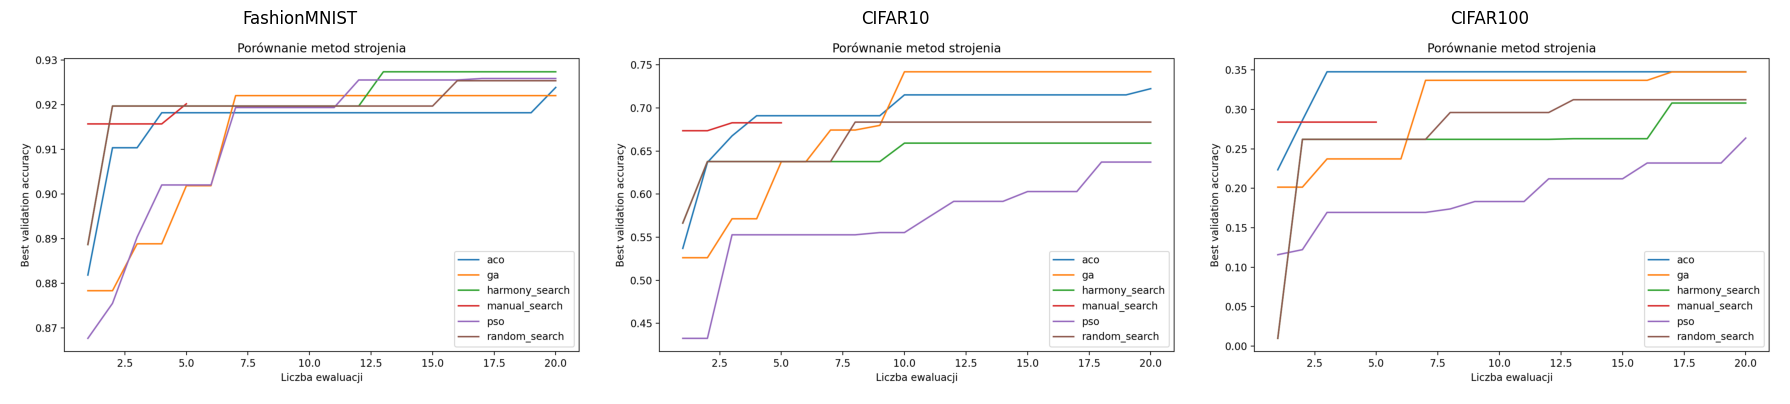

In [17]:
best_so_far_paths = {}

for dataset_name, df_dataset in results_per_dataset.items():
    dataset_csv = os.path.join(TABLES_DIR, f"all_methods_{dataset_name}.csv")
    fig_path = os.path.join(FIGURES_DIR, f"best_so_far_{dataset_name}.png")
    plot_best_so_far(dataset_csv, fig_path)
    best_so_far_paths[dataset_name] = fig_path
    print("Saved:", fig_path)

fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 5))
if len(DATASETS) == 1:
    axes = [axes]
for ax, dataset_name in zip(axes, DATASETS):
    img = plt.imread(best_so_far_paths[dataset_name])
    ax.imshow(img)
    ax.set_title(dataset_name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Wykresy time-to-best per zbiór danych

In [18]:
time_to_best_per_dataset = {}

for dataset_name, df_dataset in results_per_dataset.items():
    ttb_csv = os.path.join(TABLES_DIR, f"time_to_best_{dataset_name}.csv")
    ttb_df = save_time_to_best(df_dataset, ttb_csv)
    time_to_best_per_dataset[dataset_name] = ttb_df

    fig_path = os.path.join(FIGURES_DIR, f"time_to_best_{dataset_name}.png")
    plot_time_to_best(ttb_df, fig_path)
    print("Saved:", fig_path)

pd.concat(
    [df.assign(dataset=name) for name, df in time_to_best_per_dataset.items()],
    ignore_index=True,
)

Saved: results/figures/time_to_best_FashionMNIST.png
Saved: results/figures/time_to_best_CIFAR10.png
Saved: results/figures/time_to_best_CIFAR100.png


,method,best_val_accuracy,test_accuracy_at_best,iteration_of_best,time_of_best_sec,total_time_sec,dataset
0,harmony_search,0.927333,0.9193,13,305.555912,512.108040,FashionMNIST
1,pso,0.925833,0.9167,17,315.961272,360.858128,FashionMNIST
2,random_search,0.925333,0.9179,16,444.121042,571.272521,FashionMNIST
3,aco,0.923833,0.9177,20,626.735141,626.735141,FashionMNIST
4,ga,0.922000,0.9121,7,199.225514,569.913277,FashionMNIST
5,manual_search,0.920167,0.9159,5,123.620874,123.620874,FashionMNIST
6,ga,0.742000,0.7406,10,308.692142,691.618008,CIFAR10
7,aco,0.722400,0.7181,20,521.848422,521.848422,CIFAR10
8,random_search,0.683600,0.6878,8,211.773110,546.085966,CIFAR10
9,manual_search,0.682800,0.6859,3,56.778996,114.498872,CIFAR10


## 9. Hyperparameter correlation heatmaps (per zbiór danych, per metoda)

In [19]:
for dataset_name, df_dataset in results_per_dataset.items():
    out_dir = os.path.join(FIGURES_DIR, f"hyperparam_correlations_{dataset_name}")
    plot_hyperparam_metric_correlation_heatmaps_by_method(df_dataset, out_dir)
    print("Saved heatmaps for", dataset_name, "to", out_dir)

Saved heatmaps for FashionMNIST to results/figures/hyperparam_correlations_FashionMNIST
Saved heatmaps for CIFAR10 to results/figures/hyperparam_correlations_CIFAR10
Saved heatmaps for CIFAR100 to results/figures/hyperparam_correlations_CIFAR100


## 10. Tabele podsumowujące (per zbiór danych)

In [20]:
summaries = {}
for dataset_name, df_dataset in results_per_dataset.items():
    summary_path = os.path.join(TABLES_DIR, f"method_summary_{dataset_name}.csv")
    summary = save_method_summary(df_dataset, summary_path)
    summaries[dataset_name] = summary
    print(f"\n=== {dataset_name} ===")
    display(summary)


=== FashionMNIST ===


val_accuracy                 test_accuracy                  \
                        max    mean     std           max    mean     std   
method                                                                      
aco                  0.9238  0.8942  0.0246        0.9177  0.8893  0.0261   
ga                   0.9220  0.9042  0.0190        0.9168  0.8986  0.0188   
harmony_search       0.9273  0.9075  0.0166        0.9221  0.9044  0.0171   
manual_search        0.9202  0.9057  0.0125        0.9159  0.9007  0.0127   
pso                  0.9258  0.8991  0.0317        0.9213  0.8930  0.0339   
random_search        0.9253  0.8612  0.1778        0.9184  0.8550  0.1790   

               time_sec                   num_params                           
                    max     mean      std        max       mean           std  
method                                                                         
aco             60.0863  31.3368  12.6449    3589482  1225555.6  1.026992e+06  
ga              50.5343  28.4957   8.7068    3325066  1931812.4  1.245178e+06  
harmony_search  40.6346  25.6054   8.5152    3251658  1078751.6  1.068991e+06  
manual_search   30.7464  24.7242   6.7832    1736906   868272.4  5.253012e+05  
pso             37.4230  18.0429   6.7214    1644618  1056434.0  6.147549e+05  
random_search   58.4396  28.5636  12.8757    3251658  1192400.4  8.597084e+05


=== CIFAR10 ===


val_accuracy                 test_accuracy                  \
                        max    mean     std           max    mean     std   
method                                                                      
aco                  0.7224  0.5794  0.1324        0.7181  0.5795  0.1321   
ga                   0.7420  0.6652  0.0815        0.7406  0.6639  0.0819   
harmony_search       0.6592  0.5787  0.1204        0.6580  0.5774  0.1199   
manual_search        0.6828  0.6557  0.0242        0.6859  0.6607  0.0226   
pso                  0.6372  0.4614  0.1936        0.6343  0.4580  0.1941   
random_search        0.6836  0.5354  0.1608        0.6878  0.5346  0.1615   

               time_sec                   num_params                           
                    max     mean      std        max       mean           std  
method                                                                         
aco             61.2011  26.0924  12.6062    4235850  1877814.0  1.501585e+06  
ga              55.3384  34.5809  10.4989    4304458  1395740.4  1.030057e+06  
harmony_search  36.8097  23.3957   7.0824    4235850  1089049.2  1.052378e+06  
manual_search   31.1926  22.8998   6.0374    2196810  1106736.4  6.641179e+05  
pso             23.2338  14.2418   2.8620    2137290   407561.2  4.230590e+05  
random_search   56.5912  27.3043  11.0444    4235850  1437328.4  1.010515e+06


=== CIFAR100 ===


val_accuracy                 test_accuracy                  \
                        max    mean     std           max    mean     std   
method                                                                      
aco                  0.3476  0.2230  0.0916        0.3443  0.2231  0.0909   
ga                   0.3474  0.2567  0.0800        0.3500  0.2575  0.0809   
harmony_search       0.3080  0.2090  0.0839        0.3191  0.2105  0.0854   
manual_search        0.2840  0.2630  0.0268        0.2845  0.2671  0.0235   
pso                  0.2636  0.1504  0.0804        0.2658  0.1512  0.0820   
random_search        0.3122  0.1650  0.1122        0.3171  0.1672  0.1138   

               time_sec                   num_params                           
                    max     mean      std        max       mean           std  
method                                                                         
aco             61.2015  27.1949  13.4799    4258980  1814047.2  1.519831e+06  
ga              55.4107  32.7197  12.9076    4327588  2407412.8  1.609356e+06  
harmony_search  49.2807  27.2867   8.7963    4258980   953820.8  9.553040e+05  
manual_search   30.9731  25.2313   6.3806    2219940  1122954.4  6.689022e+05  
pso             22.0920  13.9243   2.6425    2148900   480426.4  4.410409e+05  
random_search   56.1240  27.1358  10.9323    4258980  1449514.4  1.011882e+06

## 11. Najlepsze konfiguracje na każdy zbiór danych x metodę

In [21]:
best_configs_per_dataset = {}
for dataset_name, df_dataset in results_per_dataset.items():
    best_path = os.path.join(TABLES_DIR, f"best_configs_{dataset_name}.csv")
    best_df = save_best_configs(df_dataset, best_path)
    best_configs_per_dataset[dataset_name] = best_df
    print(f"\n=== Best per method on {dataset_name} ===")
    display(best_df[[
        "method",
        "iteration",
        "learning_rate",
        "batch_size",
        "num_blocks",
        "filters_1",
        "filters_2",
        "filters_3",
        "kernel_size",
        "dropout",
        "dense_units",
        "val_accuracy",
        "test_accuracy",
        "time_sec",
        "num_params",
    ]])


=== Best per method on FashionMNIST ===


,method,iteration,learning_rate,batch_size,num_blocks,filters_1,filters_2,filters_3,kernel_size,dropout,dense_units,val_accuracy,test_accuracy,time_sec,num_params
0,harmony_search,13,0.001428,32,1,64,32,64,3,0.030306,256,0.927333,0.9193,31.524582,3251658
1,pso,17,0.001609,128,1,64,128,256,3,0.148324,128,0.925833,0.9167,14.414840,1644618
2,random_search,16,0.001503,32,1,64,128,64,3,0.033700,64,0.925333,0.9179,27.310582,841098
3,aco,20,0.000703,32,2,64,128,64,5,0.233512,128,0.923833,0.9177,46.703598,1523018
4,ga,7,0.000340,64,1,64,64,64,5,0.464509,256,0.922000,0.9121,24.322041,3318218
5,manual_search,5,0.000800,32,1,32,64,128,5,0.200000,128,0.920167,0.9159,30.746407,830698



=== Best per method on CIFAR10 ===


,method,iteration,learning_rate,batch_size,num_blocks,filters_1,filters_2,filters_3,kernel_size,dropout,dense_units,val_accuracy,test_accuracy,time_sec,num_params
0,ga,10,0.000340,32,3,64,64,128,3,0.151937,256,0.7420,0.7406,33.725230,861130
1,aco,20,0.000703,128,2,64,128,64,3,0.233512,256,0.7224,0.7181,24.444602,2360138
2,random_search,8,0.000634,32,1,64,128,128,3,0.327719,128,0.6836,0.6878,27.641566,2137290
3,manual_search,3,0.001000,64,3,32,64,128,3,0.350000,128,0.6828,0.6859,21.834718,550570
4,harmony_search,10,0.002253,32,1,32,32,128,3,0.030306,256,0.6592,0.6580,25.146023,2110122
5,pso,18,0.005765,256,2,32,32,128,3,0.000000,64,0.6372,0.6343,12.500652,160426



=== Best per method on CIFAR100 ===


,method,iteration,learning_rate,batch_size,num_blocks,filters_1,filters_2,filters_3,kernel_size,dropout,dense_units,val_accuracy,test_accuracy,time_sec,num_params
0,aco,3,0.000471,256,1,64,128,128,3,0.046373,256,0.3476,0.3443,15.153901,4258980
1,ga,17,0.000130,32,2,64,128,64,5,0.201888,256,0.3474,0.3500,52.799724,2845092
2,random_search,13,0.001577,256,1,16,64,128,3,0.028963,256,0.3122,0.3171,11.505154,1077300
3,harmony_search,17,0.001517,64,1,16,32,64,3,0.030306,256,0.3080,0.3191,19.300674,1077300
4,manual_search,1,0.001000,64,2,32,64,128,3,0.250000,128,0.2840,0.2838,29.946430,602884
5,pso,20,0.006212,256,2,16,64,128,3,0.017155,128,0.2636,0.2658,12.702164,586292


## 12. Wykres jakość vs skumulowany czas

In [22]:
def plot_best_so_far_vs_time(df: pd.DataFrame, output_path: str, title: str) -> None:
    plt.figure(figsize=(8, 5))
    for method, group in df.groupby("method"):
        group = group.sort_values("iteration").copy()
        group["cum_time_sec"] = group["time_sec"].cumsum()
        group["best_so_far"] = group["val_accuracy"].cummax()
        plt.plot(group["cum_time_sec"], group["best_so_far"], label=method)
    plt.xlabel("Skumulowany czas [s]")
    plt.ylabel("Best validation accuracy")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()

for dataset_name, df_dataset in results_per_dataset.items():
    fig_path = os.path.join(FIGURES_DIR, f"best_so_far_vs_time_{dataset_name}.png")
    plot_best_so_far_vs_time(df_dataset, fig_path, f"Quality vs cumulative time - {dataset_name}")
    print("Saved:", fig_path)

Saved: results/figures/best_so_far_vs_time_FashionMNIST.png
Saved: results/figures/best_so_far_vs_time_CIFAR10.png
Saved: results/figures/best_so_far_vs_time_CIFAR100.png


## 13. Cross-dataset: najlepsza val_accuracy per metoda x zbiór

Saved: results/tables/cross_dataset_best_val_accuracy.csv


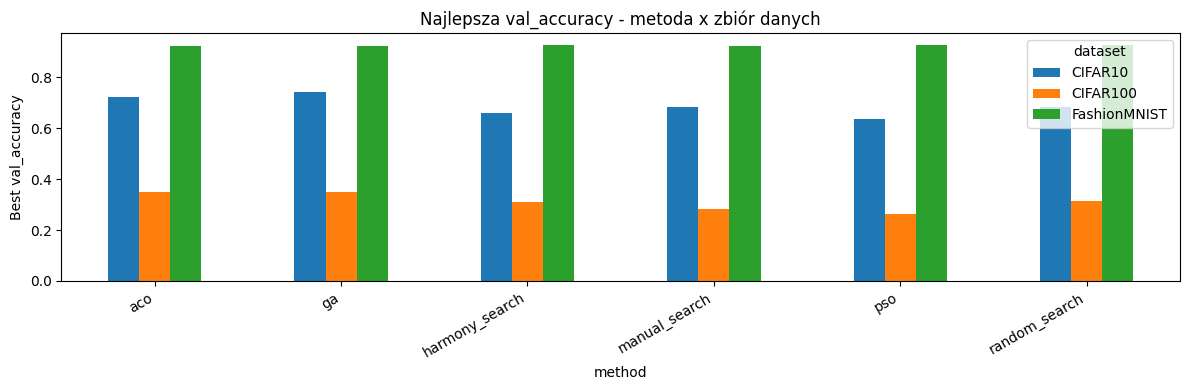

Saved: results/figures/cross_dataset_best_val_accuracy.png


dataset,CIFAR10,CIFAR100,FashionMNIST
method,,,
aco,0.7224,0.3476,0.9238
ga,0.7420,0.3474,0.9220
harmony_search,0.6592,0.3080,0.9273
manual_search,0.6828,0.2840,0.9202
pso,0.6372,0.2636,0.9258
random_search,0.6836,0.3122,0.9253


In [23]:
cross = (
    df_all.groupby(["dataset", "method"])["val_accuracy"].max().unstack("dataset").round(4)
)
cross_path = os.path.join(TABLES_DIR, "cross_dataset_best_val_accuracy.csv")
cross.to_csv(cross_path)
print("Saved:", cross_path)

fig, ax = plt.subplots(figsize=(1.5 * len(METHODS) + 3, 4))
cross.plot(kind="bar", ax=ax)
ax.set_ylabel("Best val_accuracy")
ax.set_title("Najlepsza val_accuracy - metoda x zbiór danych")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
cross_fig_path = os.path.join(FIGURES_DIR, "cross_dataset_best_val_accuracy.png")
plt.savefig(cross_fig_path, dpi=200)
plt.show()
print("Saved:", cross_fig_path)
cross

## 14. Final retraining najlepszych konfiguracji

Dla każdej pary (zbiór danych, metoda) bierzemy najlepszą konfigurację ze stage'u wyszukiwania i dotrenowujemy ją na większej liczbie epok.

In [24]:
FINAL_EPOCHS = 20
FINAL_SEED = 42

print("Final retraining epochs:", FINAL_EPOCHS)

Final retraining epochs: 20


In [25]:
from src.datasets import get_dataset_loaders
from src.model import TunableCNN
from src.train import train_one_epoch, evaluate
from src.utils import count_parameters
from torch.optim import Adam


def retrain_best_config(
    config: dict,
    dataset_name: str,
    epochs: int,
    device: str,
    seed: int = 42,
    val_split: float = 0.1,
    num_workers: int = 2,
):
    import numpy as np
    import torch

    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    train_loader, val_loader, test_loader, image_channels, image_size, num_classes = get_dataset_loaders(
        dataset_name=dataset_name,
        batch_size=int(config["batch_size"]),
        val_split=val_split,
        num_workers=num_workers,
        seed=seed,
    )

    model = TunableCNN(
        image_channels=image_channels,
        image_size=image_size,
        num_classes=num_classes,
        num_blocks=int(config["num_blocks"]),
        filters_1=int(config["filters_1"]),
        filters_2=int(config["filters_2"]),
        filters_3=int(config["filters_3"]),
        kernel_size=int(config["kernel_size"]),
        dropout=float(config["dropout"]),
        dense_units=int(config["dense_units"]),
    ).to(device)

    optimizer = Adam(model.parameters(), lr=float(config["learning_rate"]))

    history = []
    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, device)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc = evaluate(model, test_loader, device)

    return {
        "best_val_acc_retrain": best_val_acc,
        "final_test_acc": test_acc,
        "final_test_loss": test_loss,
        "num_params": count_parameters(model),
        "history": pd.DataFrame(history),
    }

In [26]:
final_results = []
history_frames = []

for dataset_name, best_df in best_configs_per_dataset.items():
    for _, row in best_df.iterrows():
        method = row["method"]
        config = {
            "learning_rate": row["learning_rate"],
            "batch_size": row["batch_size"],
            "num_blocks": row["num_blocks"],
            "filters_1": row["filters_1"],
            "filters_2": row["filters_2"],
            "filters_3": row["filters_3"],
            "kernel_size": row["kernel_size"],
            "dropout": row["dropout"],
            "dense_units": row["dense_units"],
        }

        print(f"\n=== Final retraining: {dataset_name} / {method} ===")
        print(config)

        out = retrain_best_config(
            config=config,
            dataset_name=dataset_name,
            epochs=FINAL_EPOCHS,
            device=device,
            seed=FINAL_SEED,
        )

        final_results.append({
            "dataset": dataset_name,
            "method": method,
            "search_best_val_accuracy": row["val_accuracy"],
            "search_test_accuracy": row["test_accuracy"],
            "retrain_best_val_accuracy": out["best_val_acc_retrain"],
            "final_test_accuracy": out["final_test_acc"],
            "final_test_loss": out["final_test_loss"],
            "num_params": out["num_params"],
        })

        hist = out["history"].copy()
        hist["dataset"] = dataset_name
        hist["method"] = method
        history_frames.append(hist)

final_results_df = pd.DataFrame(final_results).sort_values(
    ["dataset", "final_test_accuracy"], ascending=[True, False]
)
final_history_df = pd.concat(history_frames, ignore_index=True)

final_results_df


=== Final retraining: FashionMNIST / harmony_search ===
{'learning_rate': 0.001427921361121902, 'batch_size': 32, 'num_blocks': 1, 'filters_1': 64, 'filters_2': 32, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.030306337038506825, 'dense_units': 256}

=== Final retraining: FashionMNIST / pso ===
{'learning_rate': 0.00160901906371031, 'batch_size': 128, 'num_blocks': 1, 'filters_1': 64, 'filters_2': 128, 'filters_3': 256, 'kernel_size': 3, 'dropout': 0.1483242480178807, 'dense_units': 128}

=== Final retraining: FashionMNIST / random_search ===
{'learning_rate': 0.001502727481746676, 'batch_size': 32, 'num_blocks': 1, 'filters_1': 64, 'filters_2': 128, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.03370016405515375, 'dense_units': 64}

=== Final retraining: FashionMNIST / aco ===
{'learning_rate': 0.0007033269290478107, 'batch_size': 32, 'num_blocks': 2, 'filters_1': 64, 'filters_2': 128, 'filters_3': 64, 'kernel_size': 5, 'dropout': 0.2335123340183375, 'dense_units': 128}

=== Fin

/home/jgrzes/cnn-metaheuristics/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



=== Final retraining: CIFAR10 / aco ===
{'learning_rate': 0.0007033269290478107, 'batch_size': 128, 'num_blocks': 2, 'filters_1': 64, 'filters_2': 128, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.2335123340183375, 'dense_units': 256}

=== Final retraining: CIFAR10 / random_search ===
{'learning_rate': 0.0006343509199762545, 'batch_size': 32, 'num_blocks': 1, 'filters_1': 64, 'filters_2': 128, 'filters_3': 128, 'kernel_size': 3, 'dropout': 0.32771933264744, 'dense_units': 128}

=== Final retraining: CIFAR10 / manual_search ===
{'learning_rate': 0.001, 'batch_size': 64, 'num_blocks': 3, 'filters_1': 32, 'filters_2': 64, 'filters_3': 128, 'kernel_size': 3, 'dropout': 0.35, 'dense_units': 128}

=== Final retraining: CIFAR10 / harmony_search ===
{'learning_rate': 0.0022532106319453774, 'batch_size': 32, 'num_blocks': 1, 'filters_1': 32, 'filters_2': 32, 'filters_3': 128, 'kernel_size': 3, 'dropout': 0.030306337038506825, 'dense_units': 256}

=== Final retraining: CIFAR10 / pso ===
{'le

/home/jgrzes/cnn-metaheuristics/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



=== Final retraining: CIFAR100 / ga ===
{'learning_rate': 0.00012994487612816188, 'batch_size': 32, 'num_blocks': 2, 'filters_1': 64, 'filters_2': 128, 'filters_3': 64, 'kernel_size': 5, 'dropout': 0.20188777565913874, 'dense_units': 256}

=== Final retraining: CIFAR100 / random_search ===
{'learning_rate': 0.0015772087178392035, 'batch_size': 256, 'num_blocks': 1, 'filters_1': 16, 'filters_2': 64, 'filters_3': 128, 'kernel_size': 3, 'dropout': 0.028962583247093776, 'dense_units': 256}

=== Final retraining: CIFAR100 / harmony_search ===
{'learning_rate': 0.0015169980582701848, 'batch_size': 64, 'num_blocks': 1, 'filters_1': 16, 'filters_2': 32, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.030306337038506825, 'dense_units': 256}

=== Final retraining: CIFAR100 / manual_search ===
{'learning_rate': 0.001, 'batch_size': 64, 'num_blocks': 2, 'filters_1': 32, 'filters_2': 64, 'filters_3': 128, 'kernel_size': 3, 'dropout': 0.25, 'dense_units': 128}

=== Final retraining: CIFAR100 / pso 

,dataset,method,search_best_val_accuracy,search_test_accuracy,retrain_best_val_accuracy,final_test_accuracy,final_test_loss,num_params
6,CIFAR10,ga,0.742000,0.7406,0.810400,0.8092,0.705202,861130
9,CIFAR10,manual_search,0.682800,0.6859,0.782200,0.7772,0.657455,550570
7,CIFAR10,aco,0.722400,0.7181,0.787800,0.7744,0.782054,2360138
8,CIFAR10,random_search,0.683600,0.6878,0.706600,0.6976,0.889812,2137290
11,CIFAR10,pso,0.637200,0.6343,0.683200,0.6710,0.953523,160426
10,CIFAR10,harmony_search,0.659200,0.6580,0.659200,0.6546,1.018733,2110122
13,CIFAR100,ga,0.347400,0.3500,0.432600,0.4314,2.490795,2845092
16,CIFAR100,manual_search,0.284000,0.2838,0.398800,0.4064,2.308201,602884
12,CIFAR100,aco,0.347600,0.3443,0.359800,0.3605,2.597507,4258980
14,CIFAR100,random_search,0.312200,0.3171,0.337800,0.3392,2.840641,1077300


## 15. Zapis wyników finalnego retrainingu

In [27]:
final_results_path = os.path.join(TABLES_DIR, "final_retraining_results.csv")
final_history_path = os.path.join(TABLES_DIR, "final_retraining_history.csv")

final_results_df.to_csv(final_results_path, index=False)
final_history_df.to_csv(final_history_path, index=False)

print("Saved final retraining results to:", final_results_path)
print("Saved final retraining history to:", final_history_path)

Saved final retraining results to: results/tables/final_retraining_results.csv
Saved final retraining history to: results/tables/final_retraining_history.csv


## 16. Wykresy finalnego treningu (per zbiór danych)

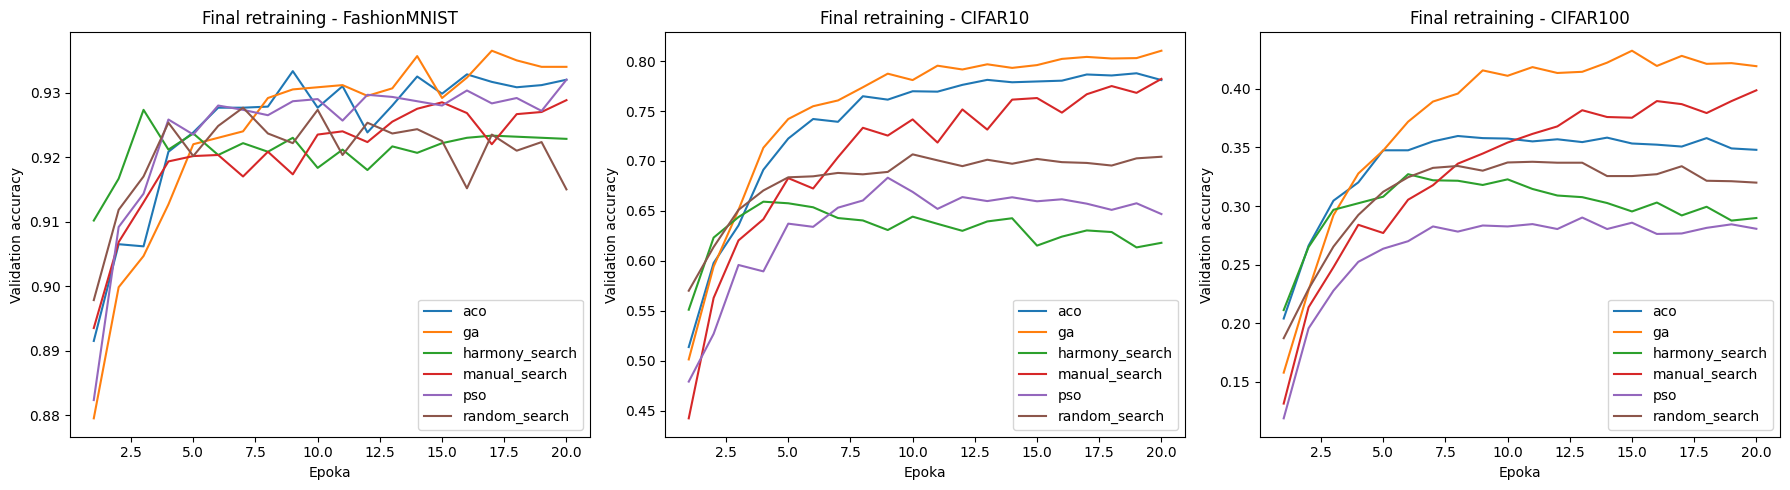

Saved: results/figures/final_retraining_val_curves.png


In [28]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 5), sharey=False)
if len(DATASETS) == 1:
    axes = [axes]

for ax, dataset_name in zip(axes, DATASETS):
    subset = final_history_df[final_history_df["dataset"] == dataset_name]
    for method, group in subset.groupby("method"):
        ax.plot(group["epoch"], group["val_acc"], label=method)
    ax.set_title(f"Final retraining - {dataset_name}")
    ax.set_xlabel("Epoka")
    ax.set_ylabel("Validation accuracy")
    ax.legend()

plt.tight_layout()
final_curves_path = os.path.join(FIGURES_DIR, "final_retraining_val_curves.png")
plt.savefig(final_curves_path, dpi=200)
plt.show()
print("Saved:", final_curves_path)

## 17. Final test accuracy - metoda x zbiór danych

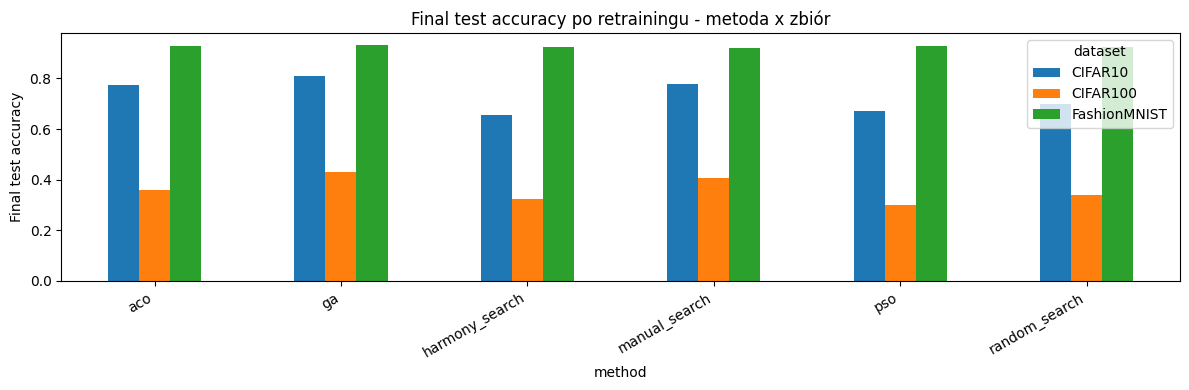

Saved: results/tables/final_test_accuracy_pivot.csv
Saved: results/figures/final_test_accuracy_pivot.png


dataset,CIFAR10,CIFAR100,FashionMNIST
method,,,
aco,0.7744,0.3605,0.9264
ga,0.8092,0.4314,0.9331
harmony_search,0.6546,0.3250,0.9249
manual_search,0.7772,0.4064,0.9213
pso,0.6710,0.2998,0.9274
random_search,0.6976,0.3392,0.9225


In [29]:
final_pivot = (
    final_results_df.pivot(index="method", columns="dataset", values="final_test_accuracy").round(4)
)
final_pivot_path = os.path.join(TABLES_DIR, "final_test_accuracy_pivot.csv")
final_pivot.to_csv(final_pivot_path)

fig, ax = plt.subplots(figsize=(1.5 * len(METHODS) + 3, 4))
final_pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Final test accuracy")
ax.set_title("Final test accuracy po retrainingu - metoda x zbiór")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
final_pivot_fig_path = os.path.join(FIGURES_DIR, "final_test_accuracy_pivot.png")
plt.savefig(final_pivot_fig_path, dpi=200)
plt.show()
print("Saved:", final_pivot_path)
print("Saved:", final_pivot_fig_path)
final_pivot

## 18. Końcowa tabela do raportu

In [30]:
analysis_rows = []
for dataset_name, df_dataset in results_per_dataset.items():
    agg = (
        df_dataset.groupby("method", as_index=False)
        .agg(
            best_val_accuracy=("val_accuracy", "max"),
            mean_val_accuracy=("val_accuracy", "mean"),
            best_test_accuracy=("test_accuracy", "max"),
            mean_time_sec=("time_sec", "mean"),
            total_time_sec=("time_sec", "sum"),
            mean_num_params=("num_params", "mean"),
        )
    )
    agg["dataset"] = dataset_name
    analysis_rows.append(agg)

analysis_df = pd.concat(analysis_rows, ignore_index=True)

report_table = final_results_df.merge(
    analysis_df[["dataset", "method", "total_time_sec"]],
    on=["dataset", "method"],
    how="left",
)

report_table = report_table[[
    "dataset",
    "method",
    "search_best_val_accuracy",
    "retrain_best_val_accuracy",
    "final_test_accuracy",
    "total_time_sec",
    "num_params",
]].sort_values(["dataset", "final_test_accuracy"], ascending=[True, False])

report_path = os.path.join(TABLES_DIR, "final_report_table.csv")
report_table.to_csv(report_path, index=False)
print("Saved:", report_path)
report_table

Saved: results/tables/final_report_table.csv


,dataset,method,search_best_val_accuracy,retrain_best_val_accuracy,final_test_accuracy,total_time_sec,num_params
0,CIFAR10,ga,0.742000,0.810400,0.8092,691.618008,861130
1,CIFAR10,manual_search,0.682800,0.782200,0.7772,114.498872,550570
2,CIFAR10,aco,0.722400,0.787800,0.7744,521.848422,2360138
3,CIFAR10,random_search,0.683600,0.706600,0.6976,546.085966,2137290
4,CIFAR10,pso,0.637200,0.683200,0.6710,284.835923,160426
5,CIFAR10,harmony_search,0.659200,0.659200,0.6546,467.913887,2110122
6,CIFAR100,ga,0.347400,0.432600,0.4314,654.393829,2845092
7,CIFAR100,manual_search,0.284000,0.398800,0.4064,126.156737,602884
8,CIFAR100,aco,0.347600,0.359800,0.3605,543.898781,4258980
9,CIFAR100,random_search,0.312200,0.337800,0.3392,542.715872,1077300


## 19. (Opcjonalnie) Zapis wyników na Google Drive

In [31]:
# from google.colab import drive
# drive.mount('/content/drive')
# !mkdir -p /content/drive/MyDrive/cnn-metaheuristics-results
# !cp -r {RESULTS_DIR} /content/drive/MyDrive/cnn-metaheuristics-results/